# 기초통계 과제: DailyBox 마케팅 전략 분석 (템플릿)

`marketing_assignment_instructions.md`의 문항 번호에 맞춰 빈칸(`____`)을 채우고, 마크다운 셀에 해석/결론을 서술하세요. 여러분은 DailyBox 전략팀 분석가입니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.outliers_influence import variance_inflation_factor

plt.rcParams['font.family'] = 'AppleGothic'   # Windows는 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')

df = pd.read_csv('marketing_customers.csv')
df.head()

,customer_id,age,gender,signup_channel,membership_tier,monthly_visits,avg_discount_rate,online_ad_cost,offline_ad_cost,total_ad_cost,campaign_group,responded,monthly_spend
0,1,21,Female,Organic Search,Basic,10,0.140,16.56,0.34,16.90,control,0,35.10
1,2,47,Female,Referral,Silver,7,0.037,7.45,8.00,15.45,treatment,0,55.42
2,3,42,Female,Social Ads,Silver,8,0.347,20.54,6.92,27.46,treatment,1,86.58
3,4,27,Female,Referral,Silver,5,0.269,9.98,2.80,12.78,control,0,20.63
4,5,26,Female,Social Ads,Basic,13,0.157,6.83,0.57,7.40,treatment,1,25.43


## Part 1. 고객 이해 (EDA)

**1. 데이터 로드 및 구조 확인**

In [2]:
print(df.shape)
print(df.dtypes)
print(df.describe())
print(df.isna().sum())   

(6000, 13)
customer_id            int64
age                    int64
gender                   str
signup_channel           str
membership_tier          str
monthly_visits         int64
avg_discount_rate    float64
online_ad_cost       float64
offline_ad_cost      float64
total_ad_cost        float64
campaign_group           str
responded              int64
monthly_spend        float64
dtype: object
       customer_id          age  monthly_visits  avg_discount_rate  \
count  6000.000000  6000.000000     6000.000000        6000.000000   
mean   3000.500000    40.263333        8.201500           0.171374   
std    1732.195139    11.513402        4.221437           0.096024   
min       1.000000    18.000000        1.000000           0.000000   
25%    1500.750000    32.000000        5.000000           0.098000   
50%    3000.500000    40.000000        8.000000           0.158000   
75%    4500.250000    48.000000       11.000000           0.233250   
max    6000.000000    78.000000       

In [3]:
## 수치형 변수 범위 확인

df_num = df.select_dtypes(include=['int64', 'float64'])
df_num = df_num.drop(columns=['customer_id' , 'responded'])
df_num.head(10)

,age,monthly_visits,avg_discount_rate,online_ad_cost,offline_ad_cost,total_ad_cost,monthly_spend
0,21,10,0.140,16.56,0.34,16.90,35.10
1,47,7,0.037,7.45,8.00,15.45,55.42
2,42,8,0.347,20.54,6.92,27.46,86.58
3,27,5,0.269,9.98,2.80,12.78,20.63
4,26,13,0.157,6.83,0.57,7.40,25.43
5,26,4,0.091,11.22,2.79,14.01,18.32
6,18,3,0.214,3.10,3.93,7.03,13.32
7,31,5,0.262,19.77,15.88,35.65,17.82
8,19,19,0.068,8.21,1.83,10.04,32.69
9,29,15,0.130,9.18,10.46,19.64,35.22


> ✍️ 고객 규모와 주요 수치 변수 범위를 한두 줄로 요약하세요.

## 고객 규모

- customer_id(PK): 6000 count
- 주요 수치 변수: str형을 제외한 int, float형 변수들
    - responded(binary var) 제외

- 변수별 결측치 없음

**2. 매출 분포와 로그변환** — monthly_spend 왜도 계산 + log1p 전/후 비교

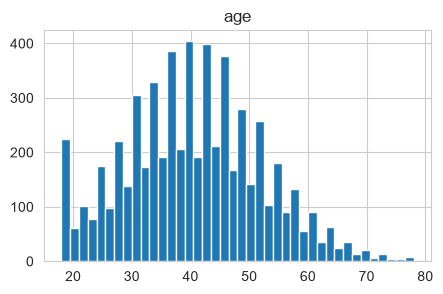

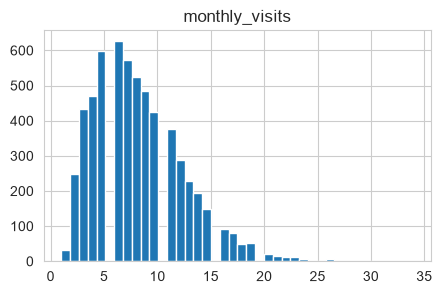

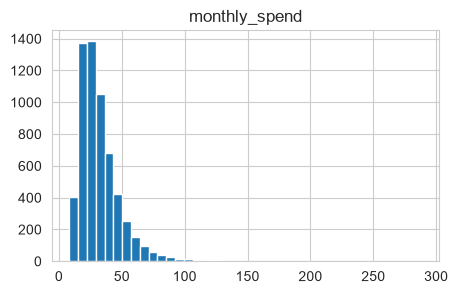

왜도 = 2.5456526289788064


/opt/homebrew/Caskroom/miniconda/base/envs/ybigta/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Caskroom/miniconda/base/envs/ybigta/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


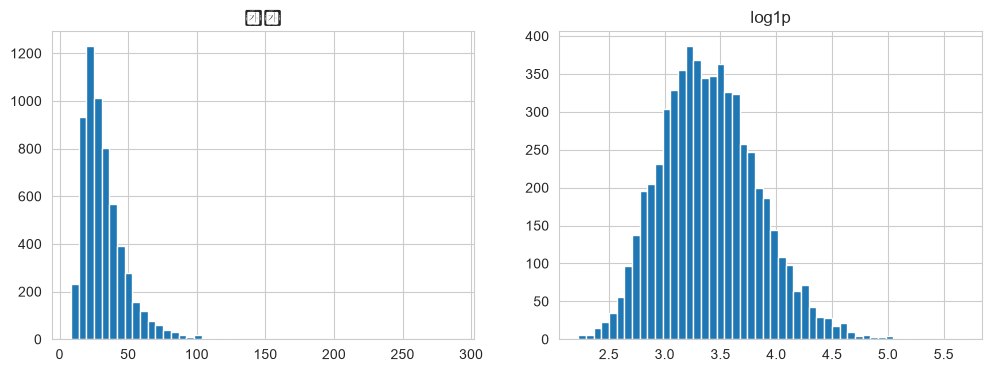

In [4]:
for col in ['age', 'monthly_visits', 'monthly_spend']:
    plt.figure(figsize=(5, 3))
    plt.hist(df[col], bins=40)
    plt.title(col); plt.show()

skew = df['monthly_spend'].skew()   # 힌트: 왜도 메서드
print('왜도 =', skew)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['monthly_spend'], bins=50);          axes[0].set_title('원본')
axes[1].hist(np.log1p(df['monthly_spend']), bins=50)  
axes[1].set_title('log1p'); plt.show()

> ✍️ 매출 분포가 왜 치우쳐 있는지, 로그변환이 왜 도움이 되는지 서술하세요.

## monthly_spend의 skewness

- skewness: 2.55
- why skewed?
    - monthly_spend(월 구매액(매출))
    - 고객마다의 구매력 차이가 존재하기 마련인데, 돈이 많은 극소수의 인원이 매우 많은 구매를 수행하여 positive skew가 발생..

---

- 로그변환이 왜 도움이 되는가?
    - positive skewed: data의 분포가 비대칭적 분포의 특성 띰
        - outlier, 비대칭성에 의해 데이터의 분산이 지나치게 커 분석에 용이하지 못함

    - 로그변환 -> 데이터의 분포를 정규분포에 가깝게 변환시킴
        - 모델이 데이터 더욱 안정적으로 학습하게 됨
        - 분산 안정화, 비대칭성 완화

**3. 채널·등급별 매출 Boxplot**

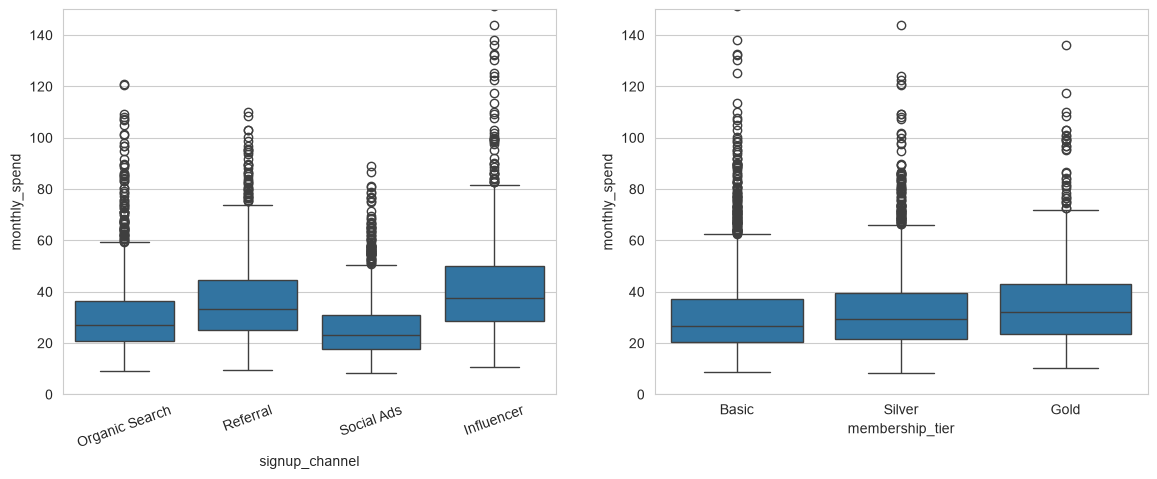

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='signup_channel', y='monthly_spend', ax=axes[0])
axes[0].set_ylim(0, 150); axes[0].tick_params(axis='x', rotation=20)
sns.boxplot(data=df, x='membership_tier', y='monthly_spend',    # 힌트: 'membership_tier'
            order=['Basic', 'Silver', 'Gold'], ax=axes[1])
axes[1].set_ylim(0, 150); plt.show()

In [6]:
## 각 컬럼(유입 채널 , 멤버십 등급) 의 value count 확인

print(df['signup_channel'].value_counts())
print('___________________________')
print(df['membership_tier'].value_counts())

signup_channel
Organic Search    2061
Social Ads        1792
Referral          1230
Influencer         917
Name: count, dtype: int64
___________________________
membership_tier
Basic     3215
Silver    2011
Gold       774
Name: count, dtype: int64


> ✍️ 어떤 채널/등급이 고가치 고객으로 보이는지 해석하세요.

## 채널 관점

- Influencer > Referral > Organic search < Social ads
    - 인플루언서: 중앙값이 가장 큼, 박스 전체가 위로 밀려올라가있음 -> 분포 자체가 통째로 높음
        - outlier가 박스 위 매우 높은곳까지 분포 -> 고가치 고객이 인플루언서 채널에 몰림
        - 인플루언서 채널이 숫자 가장 적음 + 고가치 이상치 가장 많음 -> 고가치 고객의 밀도 실제로 높다는 뜻..


## 등급 관점

- 차이 약함: Gold, Silver, Basic의 중앙값 차이 존재하긴하나 미미함
    - 박스의 IQR폭이 매우 비슷하며 박스의 위치 또한 거의 겹쳐있음

## Part 2. 가정 확인

**4. 1종/2종 오류 (개념)**

> ✍️ "쿠폰 캠페인은 효과가 없다"는 H0에 대해 1종 오류와 2종 오류가 각각 무엇을 의미하고, 어떤 손실을 끼치는지 서술하세요.

- H0: 쿠폰 캠페인은 효과가 없다
- H1: 쿠폰 캠페인은 효과가 없지 않다(효과가 있다)


----------

- 1종 오류: (False alarm) -> 귀무가설이 맞는데, reject함
    - 쿠폰 캠페인이 효과가 없는데, 효과가 없지 않다고 판단하고 캠페인을 수행함
    - 회사 입장에서 무의미한 지출이 발생함
        - 낭비되는 금액 대략 산정 가능

- 2종 오류: (Do not detect) -> 귀무가설이 틀린데, fail to reject함
    - 쿠폰 캠페인이 효과가 없지 않는데, 효과가 없다 판단하고 캠페인을 수행하지 않음
    - 회사 입장에서 잠재적인 이득을 놓쳐버리게 됨(기회비용 발생)
        - 기회비용 계산 hard

**5. 정규성 검정 (Shapiro-Wilk) — 원본 vs 로그**

/opt/homebrew/Caskroom/miniconda/base/envs/ybigta/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Caskroom/miniconda/base/envs/ybigta/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


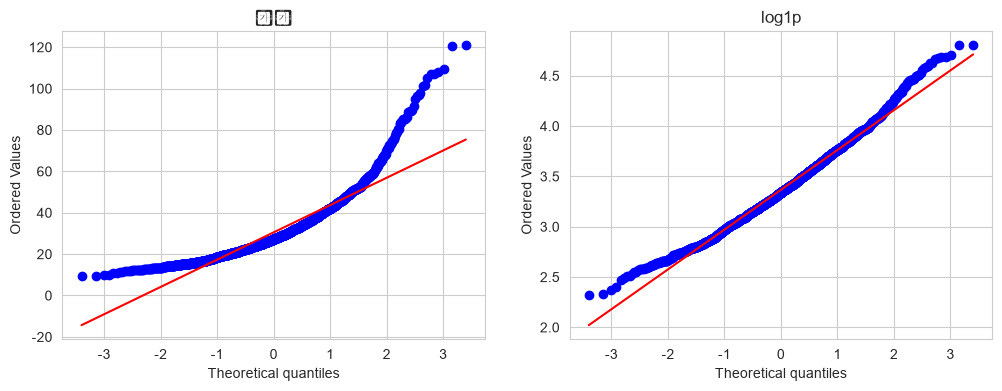

원본   ShapiroResult(statistic=np.float64(0.853453397638087), pvalue=np.float64(3.631642400264097e-21))
log1p  ShapiroResult(statistic=np.float64(0.9873230180962402), pvalue=np.float64(0.00024486116128258806))


In [7]:
x = df.loc[df.signup_channel == 'Organic Search', 'monthly_spend']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
stats.probplot(x, dist='norm', plot=axes[0]);            axes[0].set_title('원본')
stats.probplot(np.log1p(x), dist='norm', plot=axes[1]);  axes[1].set_title('log1p')
plt.show()

xs = x.sample(500, random_state=0)
print('원본  ', stats.shapiro(xs))          # 힌트: shapiro
print('log1p ', stats.shapiro(np.log1p(xs)))

In [8]:
## 엄밀한 수치형 계산..
_, p_value_origin = stats.shapiro(xs)
_, p_value_log1p = stats.shapiro(np.log1p(xs))


# 개별 데이터(원본, 로그변환)의 p-value와 유의수준 0.05 비교
if p_value_origin <= 0.05:
    print('원본 데이터 정규분포 아님')

elif p_value_origin > 0.05:
    print('원본 데이터 정규분포 따름')

if p_value_log1p <= 0.05:
    print('로그변환 데이터 정규분포 아님')

elif p_value_log1p > 0.05:
    print('로그변환 데이터 정규분포 따름')

원본 데이터 정규분포 아님
로그변환 데이터 정규분포 아님


> ✍️ 가설을 세우고, 두 결과를 0.05 기준으로 비교 해석하세요.


- H0: 데이터가 정규분포임

- p-value <= 0.05: reject the H0 -> 데이터가 정규분포가 아님
- p-value > 0.05: fail to reject the H0 -> 데이터가 정규분포임

**6. 등분산성 검정**

In [9]:
# signup_channel의 범주별 등분산성 검정

groups = [g['monthly_spend'].values for _, g in df.groupby('signup_channel')]
stat, p = stats.levene(*groups) 
print('Levene p =', p)

Levene p = 4.335927248189438e-44


In [10]:
if p <= 0.05:
    print('분산 모두 같지는 않음')

elif p > 0.05:
    print('분산 모두 동일함')

분산 모두 같지는 않음


> ✍️ p값을 0.05 기준으로 해석하고, ANOVA에 어떤 의미인지 서술하세요.

- H0: 각 집단의 분산 모두 동일함
- H1: 각 집단의 분산 모두 같지는 않음

- 유의수준 0.05 기준으로 등분산성을 만족하지 못함
    - Welch's ANOVA와 같은 등분산 가정을 요구하지 않는 분산분석을 수행해야 함

## Part 3. 집단 비교 검정

**7. 쿠폰 캠페인 효과 검증 — 두 집단 평균 비교 (Welch's t-test)**

In [11]:
ctrl = df.loc[df.campaign_group == 'control', 'monthly_spend']
trt  = df.loc[df.campaign_group == 'treatment', 'monthly_spend']  
print('평균', ctrl.mean(), trt.mean())

print('Levene p =', stats.levene(ctrl, trt).pvalue)
# 등분산이 깨지면 equal_var=False (Welch)
t, p = stats.ttest_ind(ctrl, trt, equal_var= False)         
print('t=%.2f p=%.3g' % (t, p))

평균 29.707517635203224 34.80327820046312
Levene p = 1.1644920921295873e-19
t=-11.88 p=3.86e-32


In [12]:
if p <= 0.05:
    print('두 그룹 평균 다름')

else:
    print('두 그룹 평균 같음')

두 그룹 평균 다름


> ✍️ H0/H1을 명시하고, 캠페인을 지속할지 결론 내리세요.

- H0: 두 그룹간 평균 차이가 없다
- H1: 두 그룹간 평균 차이가 없지 않다(두 그룹간 평균차이가 존재한다)

- 통계분석 결과 두 그룹(쿠폰 캠페인을 수행한 그룹/수행하지 않은 그룹)의 평균은 유의미하게 
    - trt군의 평균이 34로 더 높으므로 캠페인을 지속하는것이 더 이득임

**8. 채널 비교 — One-way ANOVA + Tukey HSD**

In [13]:
F, p = stats.f_oneway(*groups)
print('ANOVA F=%.2f p=%.3g' % (F, p))

tukey = pairwise_tukeyhsd(df['monthly_spend'], df['signup_channel'], alpha=0.05)  
print(tukey)

ANOVA F=276.85 p=2.67e-168
         Multiple Comparison of Means - Tukey HSD, FWER=0.05         
    group1         group2     meandiff p-adj  lower    upper   reject
---------------------------------------------------------------------
    Influencer Organic Search -12.3582   0.0 -13.9696 -10.7469   True
    Influencer       Referral  -6.1796   0.0  -7.9507  -4.4086   True
    Influencer     Social Ads -17.0177   0.0 -18.6659 -15.3696   True
Organic Search       Referral   6.1786   0.0    4.716   7.6412   True
Organic Search     Social Ads  -4.6595   0.0  -5.9706  -3.3484   True
      Referral     Social Ads -10.8381   0.0 -12.3412   -9.335   True
---------------------------------------------------------------------


In [14]:
if p <= 0.05:
    print('전체 그룹 중 적어도 하나 평균 다름')

else:
    print('모든 그룹 평균 같음')

전체 그룹 중 적어도 하나 평균 다름


> ✍️ 가설을 세우고, 어느 채널이 유의하게 고가치/저가치인지 결론지으세요.


- Pairwise-Tukey test
    - H0: 두 집단의 평균 차이는 통계적으로 무의미하다
    - H1: 두 집단의 평균 차이는 통계적으로 무의미하지 않다

- Influencer: x
- Organic Search: x - 12.3582
- Social Ads: x - 17.0177
- Referral: x - 6.1796

--------

- 모든 pair가 reject the null >> 모든 pair의 평균 차이는 통계적으로 유의미하다

- Influencer가 유의하게 고가치
- Social Ads가 유의하게 저가치

**9. 교호작용 — Two-way ANOVA (선택 심화)**

In [15]:
# type var >> C()로 인코딩

model = smf.ols('monthly_spend ~ C(signup_channel) * C(campaign_group)', data=df).fit()
print(sm.stats.anova_lm(model, typ=2))

                                           sum_sq      df           F  \
C(signup_channel)                    2.069851e+05     3.0  284.971525   
C(campaign_group)                    3.868639e+04     1.0  159.787112   
C(signup_channel):C(campaign_group)  6.749231e+03     3.0    9.292159   
Residual                             1.450735e+06  5992.0         NaN   

                                            PR(>F)  
C(signup_channel)                    6.336934e-173  
C(campaign_group)                     3.634363e-36  
C(signup_channel):C(campaign_group)   3.973329e-06  
Residual                                       NaN  


> ✍️ 각 주효과와 교호작용의 유의성을 해석하세요.

1. Signup_channel: PR < 0.05
2. campaign_group: PR < 0.05
3. 두 변수간의 교호작용: PR < 0.05

- 각 주효과와 교호작용은 통계적으로 유의미하다

## Part 4. 회귀분석

**10. 단순선형회귀 & 다중회귀**

In [16]:
# 단순
m1 = smf.ols('monthly_spend ~ monthly_visits', data=df).fit()   
print(m1.summary().tables[1]); print('R2 =', m1.rsquared)

                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         24.6737      0.462     53.357      0.000      23.767      25.580
monthly_visits     0.9268      0.050     18.487      0.000       0.829       1.025
R2 = 0.053909275630528386


In [17]:
# 다중 (범주형은 C()로 더미코딩)
m2 = smf.ols(
    'monthly_spend ~ monthly_visits + avg_discount_rate + online_ad_cost '
    '+ C(gender) + C(signup_channel)', data=df).fit()     #
print(m2.summary())
print('단순 adjR2=%.4f / 다중 adjR2=%.4f' % (m1.rsquared_adj, m2.rsquared_adj))

                            OLS Regression Results                            
Dep. Variable:          monthly_spend   R-squared:                       0.218
Model:                            OLS   Adj. R-squared:                  0.217
Method:                 Least Squares   F-statistic:                     238.3
Date:                Sat, 18 Jul 2026   Prob (F-statistic):          9.35e-314
Time:                        13:44:15   Log-Likelihood:                -24723.
No. Observations:                6000   AIC:                         4.946e+04
Df Residuals:                    5992   BIC:                         4.952e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In

> ✍️ 방문·할인·광고비 중 매출에 실제로 기여하는 레버는? 할인 확대는 좋은 전략인가? 채널 계수는 어떻게 해석되나?

- 방문(monthly_visits): 계수 0.9166
    - 다른 모든 단위를 고정시키고, 방문을 1단위 늘릴 떄 타깃 변수인 montly_spend가 0.9166단위 늘어난다
- 할인(avg_discount_rate): 계수 11.4233
    - 다른 모든 단위를 고정시키고, 할인을 1단위 늘릴 떄 타깃 변수인 montly_spend가 11.4233단위 늘어난다
- 광고비(online_ad_cost): 계수 0.3681
    - 다른 모든 단위를 고정시키고, 방문을 1단위 늘릴 떄 타깃 변수인 montly_spend가 0.3681단위 늘어난다

---

- 위 3가지 변수들의 P value가 모두 0.00 -> (유의수준 0.05보다 작음)
    - 3가지 변수들 모두가 매출에 기여한다고 볼 수 있다

---

- 할인의 계수가 가장 크므로, 할인 확대(할인의 단위 늘림)를 할수록 매출이 더 커진다. 따라서 할인 확대는 좋은 전략이라 볼 수 있다

---

- 채널 계수는 기준 그룹을(Influencer)로 설정하여 계수가 만들어짐
    - Organic search: 다른 모든 단위가 고정되었을 때, Organic search는 Influencer에 비해 monthly_spend가 12.1854만큼 작다
    - Referral: 다른 모든 단위가 고정되었을 때, Referral은 Influencer에 비해 monthly_spend가 5.8608만큼 작다
    - Social Ads: 다른 모든 단위가 고정되었을 때, Social Ads는 Influencer에 비해 monthly_spend가 16.6992만큼 작다

**11. 다중공선성 / VIF** — online + offline + total 모두 넣기

In [20]:
def vif_table(X):
    X = sm.add_constant(X)
    return pd.DataFrame({'feature': X.columns,
        'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]})

X_bad = df[['monthly_visits', 'online_ad_cost', 'offline_ad_cost', 'total_ad_cost']] 
print(vif_table(X_bad))

print('_'*50)

X_ok = df[['monthly_visits', 'online_ad_cost', 'offline_ad_cost']]  # total 제거
print(vif_table(X_ok))

           feature       VIF
0            const  8.212525
1   monthly_visits  1.000060
2   online_ad_cost       inf
3  offline_ad_cost       inf
4    total_ad_cost       inf
__________________________________________________
           feature       VIF
0            const  8.212525
1   monthly_visits  1.000060
2   online_ad_cost  1.000251
3  offline_ad_cost  1.000213


/opt/homebrew/Caskroom/miniconda/base/envs/ybigta/lib/python3.11/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


> ✍️ VIF에 어떤 문제가 있고 왜 그런지(total=online+offline), 어떻게 해결하는지 서술하세요.

- 세 변수 모두 집어넣음? -> ViF 모두 inf
    - total = online + offline (선형 종속 관계)
    - total은 독립적 정보 없음 -> 1 / (1 - 1)


- total_ad_cost 제거 시 ViF가 1.0 근처로 정상화됨
    - online/offline은 서로 독립적이라 공선성 없음

---
- 해결책: 합계 변수(total)과 그 구성요소(online, offline)을 함께 사용하지 않음
    - total 하나만 사용하거나, online + offline 둘만 사용하거나 해야함

**12. 잔차 진단** (+ 로그변환 비교)

/opt/homebrew/Caskroom/miniconda/base/envs/ybigta/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Caskroom/miniconda/base/envs/ybigta/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Caskroom/miniconda/base/envs/ybigta/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51092 (\N{HANGUL SYLLABLE JAN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Caskroom/miniconda/base/envs/ybigta/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Caskroom/miniconda/base/envs/ybigta/lib/python3.11/site-pa

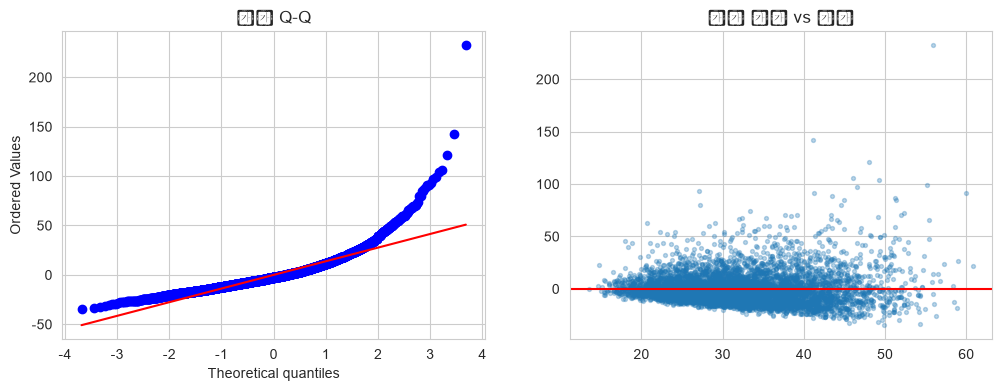

/opt/homebrew/Caskroom/miniconda/base/envs/ybigta/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 51092 (\N{HANGUL SYLLABLE JAN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Caskroom/miniconda/base/envs/ybigta/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Caskroom/miniconda/base/envs/ybigta/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/homebrew/Caskroom/miniconda/base/envs/ybigta/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


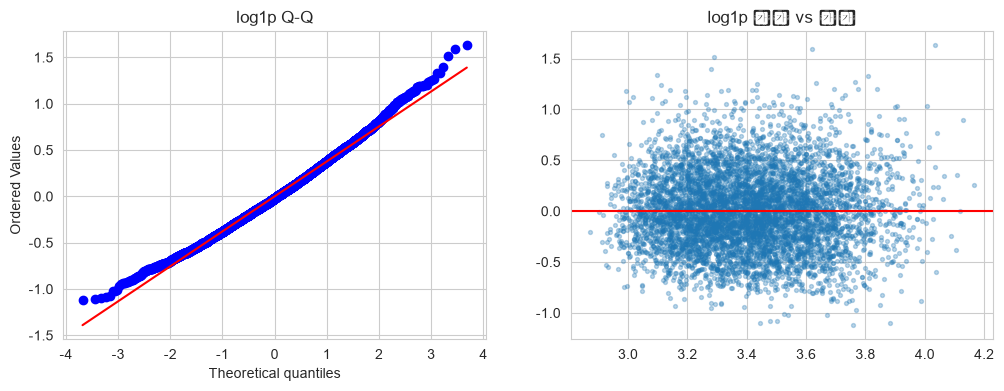

In [21]:
def resid_plots(model, title):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    stats.probplot(model.resid, dist='norm', plot=axes[0]); axes[0].set_title(title+' Q-Q')
    axes[1].scatter(model.fittedvalues, model.resid, s=8, alpha=0.3)
    axes[1].axhline(0, color='red'); axes[1].set_title(title+' 잔차 vs 예측')
    plt.show()

resid_plots(m2, '원본')

m2_log = smf.ols('np.log1p(monthly_spend) ~ monthly_visits + avg_discount_rate '
                 '+ online_ad_cost + C(signup_channel) + C(gender)', data=df).fit()
resid_plots(m2_log, 'log1p')

> ✍️ 원본 대비 로그변환 모형의 잔차가 어떻게 개선되는지 서술하세요.

### 잔차 정규성

- 원본 모형
    - 오른쪽 위가 선 위로 휘어 올라감
    - 오른쪽으로 skewed됨 -> 정규성 위반


- 로그변환 모형
    - 점들이 선에 거의 일직선으로 붙음 >> 원본에 비해 개선됨


---

### 잔차 등분산성

- 원본 모형
    - 오른쪽으로 갈수록 점들이 위로 벌어짐
    - 예측값 커질수록 잔차 분산 커짐 -> 등분산성 위반

- 로그변환 모형
    - 점들이 0선 기준으로 위아래 대칭
    - 폭 일정한 형태 -> 등분산성 만족

## Part 5. 타겟팅 (로지스틱 회귀)

**13~14. 로지스틱 회귀 & 오즈비 해석**

In [23]:
logit = smf.logit(
    'responded ~ age + monthly_visits + C(campaign_group) + C(membership_tier) '
    '+ C(signup_channel)', data=df).fit()
print(logit.summary())

odds = pd.DataFrame({'coef': logit.params, 'p': logit.pvalues,
                     'odds_ratio': np.exp(logit.params)})  
print(odds.round(3))

Optimization terminated successfully.
         Current function value: 0.512887
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:              responded   No. Observations:                 6000
Model:                          Logit   Df Residuals:                     5991
Method:                           MLE   Df Model:                            8
Date:                Sat, 18 Jul 2026   Pseudo R-squ.:                 0.06405
Time:                        14:10:13   Log-Likelihood:                -3077.3
converged:                       True   LL-Null:                       -3287.9
Covariance Type:            nonrobust   LLR p-value:                 5.453e-86
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Intercept                              -2.2301      0.157 

> ✍️ 쿠폰 발송·멤버십 등급의 오즈비를 해석하고, 다음 캠페인 타겟 세그먼트를 정하세요.

- 쿠폰 발송(기준 - 미발송): 오즈비 2.434
    - 다른 모든 조건 같을 때, 쿠폰 발송 고객은 미발송 고객에 비해 전환 오즈가 2.434배 높음
---

- 멤버십 등급(기준 - Basic)
    - Gold: 오즈비 2.019
    - Gold는 Basic 대비 전환 오즈가 2.019배 높음

    - Silver: 오즈비 1.407
    - Silver는 Basic 대비 전환 오즈가 1.407배 높음

    - 멤버 등급이 높을수록 캠페인 반응률이 높음
---

- 캠페인 타겟 세그먼트
    - Gold, Silver 등급에 우선 집중하면 반응률 높일 수 있음

## 종합 결론 — CMO 보고용 마케팅 전략

> ✍️ Part 1~5를 종합해 (1) 캠페인 지속 여부 (2) 채널 예산 배분 (3) 매출 레버 (4) 타겟팅 (5) 분석 한계를 담은 한 장짜리 전략을 서술하세요. (report.pdf의 핵심)